## Análisis de rendimiento: definición de "temporada buena vs mala"

Este notebook parte de `df_maestro.csv`, ya construido y validado en `01_exploracion_estructura.ipynb`. Aquí se define una métrica compuesta de rendimiento por temporada y se realiza el análisis exploratorio de la relación entre gasto, entrenador y rendimiento.

### Decisión de diseño: qué define una "temporada buena"

El fútbol es un deporte resultadista: el objetivo de cada temporada no es alcanzar una cifra específica de puntos, es terminar por delante del resto de la liga. Por eso, la categoría de éxito/fracaso de una temporada (`categoria_temporada`) se define exclusivamente por **posición final**, no por puntos.

Además, la escala se ajusta al contexto específico del Barça, no a un estándar genérico de club de mitad de tabla: para un club de esta escala, no clasificar a Champions League ya representa una temporada fallida, no hay una zona "aceptable" intermedia entre pelear el título y quedar fuera de Europa.

- **Título**: posición 1
- **Top 4**: posición 2 a 4 (zona de clasificación directa a Champions League)
- **Mala**: posición 5 a 8 (fuera de Champions, pero probablemente todavía dentro de zona de competición europea menor, Europa League o Conference League)
- **Catastrófico**: posición 9 en adelante (fuera de toda competición europea, sin nada que pelear el resto de la temporada)

En paralelo, se calcula `rendimiento_relativo`, una variable continua (puntos obtenidos sobre el máximo de puntos posible esa temporada específica). Esta normalización es necesaria porque los puntos crudos no son comparables entre eras: la regla de puntos por victoria cambió de 2 a 3 en 1995/96, y dos temporadas (1995/96 y 1996/97) tuvieron 42 partidos en vez de 38. `rendimiento_relativo` corrige ambas diferencias sin modificar el dato base de puntos, que se mantiene fiel a la clasificación real de cada año.

**Uso previsto de cada variable:** `categoria_temporada` se usa para comparaciones narrativas y visualizaciones (por ejemplo, cuántas temporadas de título tuvo cada entrenador). `rendimiento_relativo` se usa para análisis estadístico que requiere una variable numérica continua, como la correlación entre gasto neto y rendimiento. No se usa gasto ni entrenador como parte de la definición de "temporada buena", para evitar que el criterio de éxito quede contaminado por las mismas variables que después se van a analizar en relación a él.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr

df_maestro = pd.read_csv('../data/processed/df_maestro.csv', dtype={'temporada': str})
df_maestro.head()

,temporada,posicion,puntos,partidos_jugados,victorias,empates,derrotas,goles_favor,goles_contra,diferencia_gol,anio_inicio,entrenador_principal,hubo_cambio_entrenador,gasto_compras,ingreso_ventas,gasto_neto,fuente_gasto,gasto_total_liga,proporcion_mercado_barca
0,9394,1,56,38,25,6,7,91,42,49,1993,Johan Cruyff,False,8650000.0,0.0,8650000.0,manual,46826024.0,0.184726
1,9495,4,46,38,18,10,10,60,45,15,1994,Johan Cruyff,False,12050000.0,14850000.0,-2800000.0,manual,58083061.0,-0.048207
2,9596,3,80,42,22,14,6,72,39,33,1995,Johan Cruyff,True,16800000.0,17000000.0,-200000.0,manual,81630870.0,-0.002450
3,9697,2,90,42,28,6,8,102,48,54,1996,Bobby Robson,False,42800000.0,10920000.0,31880000.0,manual,252865057.0,0.126075
4,9798,1,74,38,23,5,10,78,56,22,1997,Louis van Gaal,False,67450000.0,40800000.0,26650000.0,manual,354451775.0,0.075187


In [31]:
df_maestro['puntos_por_victoria'] = df_maestro['temporada'].apply(lambda t: 2 if t in ['9394', '9495'] else 3)
df_maestro['puntos_maximos_posibles'] = df_maestro['partidos_jugados'] * df_maestro['puntos_por_victoria']
df_maestro['rendimiento_relativo'] = df_maestro['puntos'] / df_maestro['puntos_maximos_posibles']

df_maestro[['temporada', 'posicion', 'puntos', 'puntos_maximos_posibles', 'rendimiento_relativo']].head(10)

,temporada,posicion,puntos,puntos_maximos_posibles,rendimiento_relativo
0,9394,1,56,76,0.736842
1,9495,4,46,76,0.605263
2,9596,3,80,126,0.634921
3,9697,2,90,126,0.714286
4,9798,1,74,114,0.649123
5,9899,1,79,114,0.692982
6,9900,2,64,114,0.561404
7,0001,4,63,114,0.552632
8,0102,4,64,114,0.561404
9,0203,6,56,114,0.491228


In [32]:
def categorizar_temporada(posicion):
    if posicion == 1:
        return 'Título'
    elif posicion <= 4:
        return 'Top 4'
    elif posicion <= 8:
        return 'Mala'
    else:
        return 'Catastrófico'

df_maestro['categoria_temporada'] = df_maestro['posicion'].apply(categorizar_temporada)
df_maestro['categoria_temporada'].value_counts()

categoria_temporada
Título    16
Top 4     16
Mala       1
Name: count, dtype: int64

### Primera visualización: rendimiento relativo por temporada

El gráfico muestra tres patrones claros sin necesidad de ningún cruce adicional:

- **Valle más profundo: 2001/02**, coincidiendo con la etapa de Carles Rexach como entrenador principal, tras el cambio de Serra Ferrer a mitad de la temporada anterior. La etapa más floja del rango completo.
- **Meseta más alta: 2008-2013**, la era Guardiola-Vilanova, con el pico máximo absoluto en 2012/13 (temporada del récord de 100 puntos).
- **Caída marcada 2019-2021**, coincidiendo con la etapa de Koeman y la crisis institucional del club en ese periodo, con recuperación sostenida desde 2021/22 en adelante bajo Xavi y Flick.

Este patrón, visible antes de cruzar con gasto neto o formalizar el análisis por entrenador, sirve como primera validación de que `rendimiento_relativo` captura variación real del club a lo largo del tiempo, no ruido estadístico.

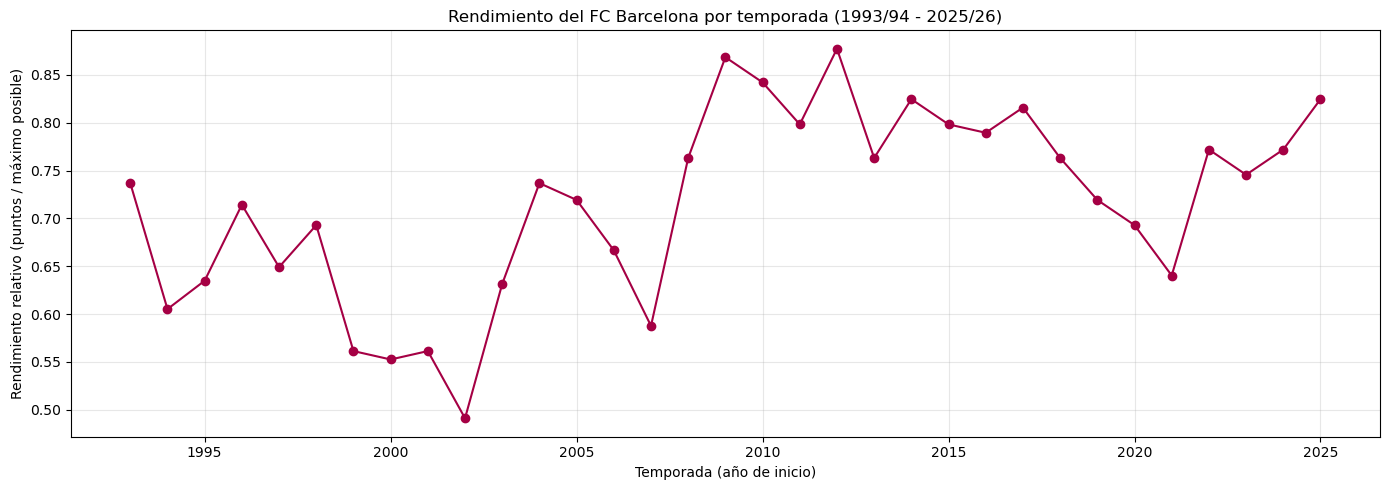

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_maestro['anio_inicio'], df_maestro['rendimiento_relativo'], marker='o', color='#a50044')
ax.set_xlabel('Temporada (año de inicio)')
ax.set_ylabel('Rendimiento relativo (puntos / máximo posible)')
ax.set_title('Rendimiento del FC Barcelona por temporada (1993/94 - 2025/26)')
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig('../reports/figures/rendimiento_por_temporada.png', dpi=150, bbox_inches='tight')
plt.show()

### Segunda visualización: proporción de mercado vs rendimiento (1993/94-2025/26)

A diferencia del primer intento (gasto absoluto, solo 12 temporadas), esta versión usa `proporcion_mercado_barca` (gasto neto del Barça como % del gasto total de La Liga esa temporada), lo que permite comparar las 33 temporadas del rango completo sin la distorsión de la inflación del mercado de fichajes entre épocas tan distintas.

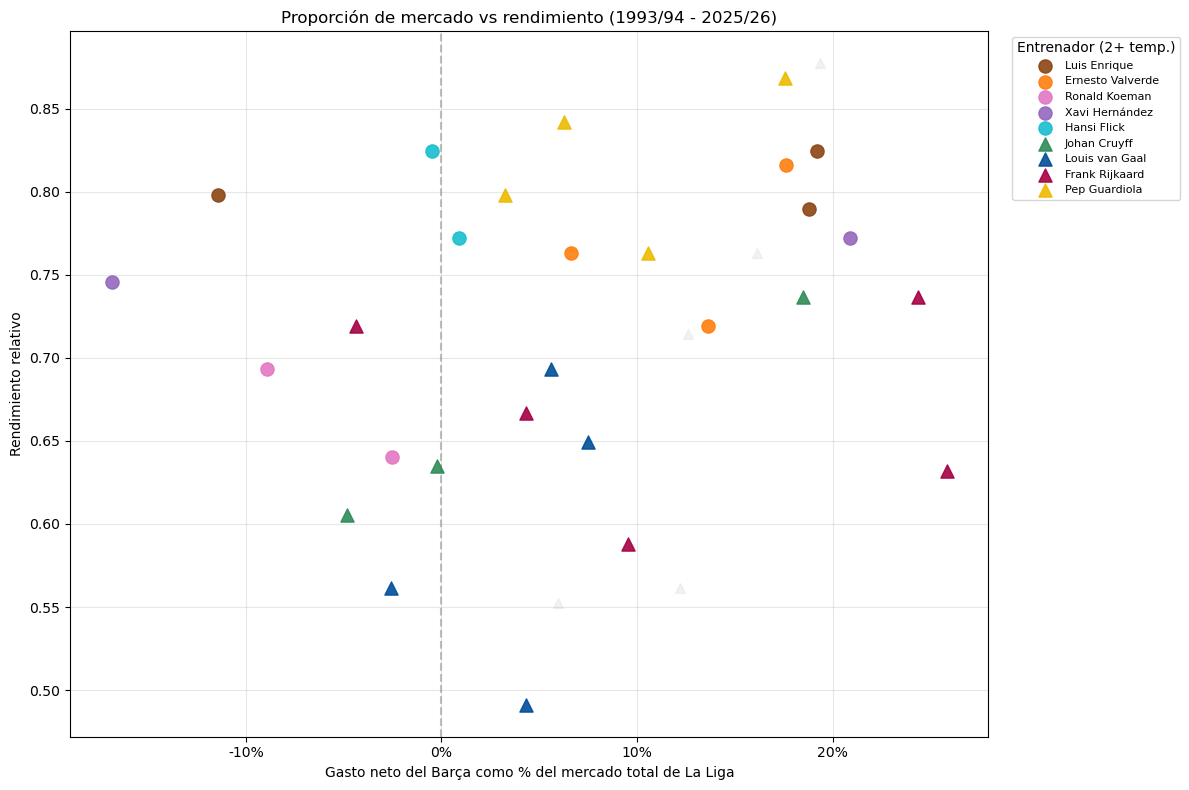

In [39]:
fig, ax = plt.subplots(figsize=(12, 8))

entrenadores_grandes = df_maestro['entrenador_principal'].value_counts()
entrenadores_grandes = entrenadores_grandes[entrenadores_grandes >= 2].index.tolist()

paleta = ['#a50044', '#004d98', '#edbb00', '#2e8b57', '#8B4513', '#ff7f0e', '#9467bd', '#17becf', '#e377c2']
mapa_color = dict(zip(entrenadores_grandes, paleta[:len(entrenadores_grandes)]))

etiquetados = set()

for fuente, marcador in [('automatizado', 'o'), ('manual', '^')]:
    subset = df_maestro[df_maestro['fuente_gasto'] == fuente]
    for entrenador in subset['entrenador_principal'].unique():
        sub = subset[subset['entrenador_principal'] == entrenador]
        es_grande = entrenador in entrenadores_grandes
        color = mapa_color.get(entrenador, '#e0e0e0')
        if es_grande and entrenador not in etiquetados:
            etiqueta = entrenador
            etiquetados.add(entrenador)
        else:
            etiqueta = None
        ax.scatter(sub['proporcion_mercado_barca'], sub['rendimiento_relativo'],
                   color=color, marker=marcador, s=90 if es_grande else 50,
                   alpha=0.9 if es_grande else 0.4, label=etiqueta,
                   zorder=3 if es_grande else 1)

ax.set_xlabel('Gasto neto del Barça como % del mercado total de La Liga')
ax.set_ylabel('Rendimiento relativo')
ax.set_title('Proporción de mercado vs rendimiento (1993/94 - 2025/26)')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Entrenador (2+ temp.)')
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig('../reports/figures/proporcion_mercado_vs_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
correlacion, p_valor = pearsonr(df_maestro['proporcion_mercado_barca'], df_maestro['rendimiento_relativo'])

print(f'Coeficiente de correlación (Pearson): {correlacion:.3f}')
print(f'Valor p: {p_valor:.3f}')

Coeficiente de correlación (Pearson): 0.227
Valor p: 0.204


### Correlación entre proporción de mercado y rendimiento (33 temporadas)

Se calculó el coeficiente de correlación de Pearson entre `proporcion_mercado_barca` y `rendimiento_relativo`, sobre las 33 temporadas completas del rango (1993/94-2025/26): **r = 0.227, p = 0.204**.

El coeficiente es débil, y aunque comparado con el análisis anterior sobre solo 12 temporadas (r = 0.207, p = 0.520) el valor p bajó considerablemente gracias al triple de tamaño de muestra, **sigue estando por encima del umbral convencional de significancia estadística (0.05)**. La conclusión se mantiene: no hay evidencia estadísticamente significativa de una relación lineal entre el gasto relativo al mercado y el rendimiento del Barça en este rango.

El gráfico de dispersión refuerza esta lectura visualmente: Hansi Flick logra el rendimiento más alto del rango completo (0.825) con gasto de mercado prácticamente nulo, mientras que Louis van Gaal, en su punto de mayor gasto relativo, produce el rendimiento más bajo de todo el rango (0.49). Dentro de un mismo entrenador (Van Gaal, con 4 temporadas de gasto similar entre sí), el rendimiento varía fuertemente, otra señal de que el nivel de inversión por sí solo no explica el resultado deportivo.

In [41]:
resumen_entrenadores = df_maestro.groupby('entrenador_principal').agg(
    temporadas=('temporada', 'count'),
    rendimiento_promedio=('rendimiento_relativo', 'mean'),
    titulos=('categoria_temporada', lambda x: (x == 'Título').sum())
).reset_index()

resumen_entrenadores = resumen_entrenadores.sort_values('rendimiento_promedio', ascending=False)
resumen_entrenadores

,entrenador_principal,temporadas,rendimiento_promedio,titulos
12,Tito Vilanova,1,0.877193,1
10,Pep Guardiola,4,0.817982,3
9,Luis Enrique,3,0.804094,2
5,Hansi Flick,2,0.798246,2
2,Ernesto Valverde,3,0.766082,2
4,Gerardo Martino,1,0.763158,0
13,Xavi Hernández,2,0.758772,1
0,Bobby Robson,1,0.714286,0
3,Frank Rijkaard,5,0.668421,2
11,Ronald Koeman,2,0.666667,0


In [42]:
resumen_confiable = resumen_entrenadores[resumen_entrenadores['temporadas'] >= 2].copy()
resumen_una_temporada = resumen_entrenadores[resumen_entrenadores['temporadas'] < 2].copy()

print('Entrenadores con 2+ temporadas:')
print(resumen_confiable)
print()
print('Entrenadores con 1 sola temporada (caso aislado, no se compara):')
print(resumen_una_temporada)

Entrenadores con 2+ temporadas:
   entrenador_principal  temporadas  rendimiento_promedio  titulos
10        Pep Guardiola           4              0.817982        3
9          Luis Enrique           3              0.804094        2
5           Hansi Flick           2              0.798246        2
2      Ernesto Valverde           3              0.766082        2
13       Xavi Hernández           2              0.758772        1
3        Frank Rijkaard           5              0.668421        2
11        Ronald Koeman           2              0.666667        0
6          Johan Cruyff           3              0.659009        1
8        Louis van Gaal           4              0.598684        2

Entrenadores con 1 sola temporada (caso aislado, no se compara):
    entrenador_principal  temporadas  rendimiento_promedio  titulos
12         Tito Vilanova           1              0.877193        1
4        Gerardo Martino           1              0.763158        0
0           Bobby Robson    

### Rendimiento promedio por entrenador (corte: 2+ temporadas)

Se separaron entrenadores con 2 o más temporadas dirigidas de aquellos con una sola temporada, tratados como casos aislados no comparables entre sí ni contra el resto. El corte de 2 temporadas no constituye una muestra estadísticamente robusta, pero permite descartar el caso más extremo de sesgo (una sola temporada atípica dominando el promedio por completo). Es un umbral práctico, declarado explícitamente como tal.

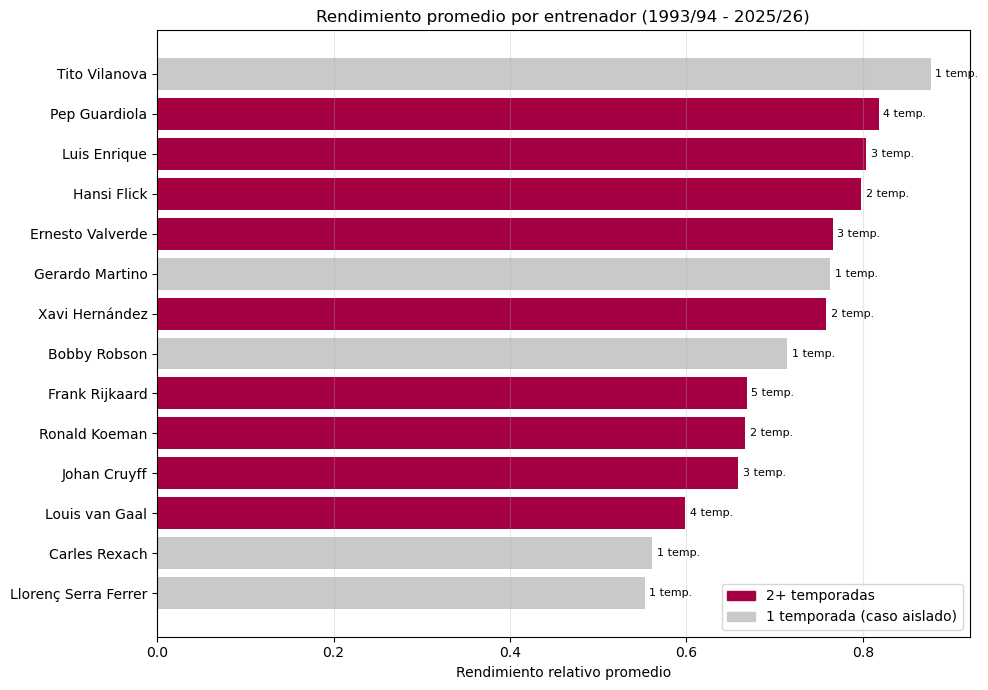

In [43]:
resumen_entrenadores['grupo'] = resumen_entrenadores['temporadas'].apply(
    lambda t: '2+ temporadas' if t >= 2 else '1 temporada (caso aislado)'
)

resumen_ordenado = resumen_entrenadores.sort_values('rendimiento_promedio', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colores_barras = resumen_ordenado['grupo'].map({
    '2+ temporadas': '#a50044',
    '1 temporada (caso aislado)': '#c9c9c9'
})

ax.barh(resumen_ordenado['entrenador_principal'], resumen_ordenado['rendimiento_promedio'], color=colores_barras)

for i, (rendimiento, temporadas) in enumerate(zip(resumen_ordenado['rendimiento_promedio'], resumen_ordenado['temporadas'])):
    ax.text(rendimiento + 0.005, i, f'{temporadas} temp.', va='center', fontsize=8)

ax.set_xlabel('Rendimiento relativo promedio')
ax.set_title('Rendimiento promedio por entrenador (1993/94 - 2025/26)')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
leyenda = [Patch(color='#a50044', label='2+ temporadas'), Patch(color='#c9c9c9', label='1 temporada (caso aislado)')]
ax.legend(handles=leyenda, loc='lower right')

plt.tight_layout()
fig.savefig('../reports/figures/rendimiento_por_entrenador.png', dpi=150, bbox_inches='tight')
plt.show()

### Análisis: rendimiento promedio por entrenador

Dentro del grupo de 2+ temporadas, **Pep Guardiola lidera con claridad** (0.818 de rendimiento promedio, 3 títulos en 4 temporadas), seguido de cerca por **Luis Enrique** (0.804, 2 títulos en 3 temporadas) y **Hansi Flick** (0.798, 2 títulos en solo 2 temporadas, aunque con la muestra más chica del grupo, un inicio de etapa muy fuerte a confirmar con más datos en el futuro).

**Louis van Gaal tiene el rendimiento promedio más bajo del grupo confiable** (0.599), pese a dirigir 4 temporadas en dos etapas distintas y ganar 2 títulos, reflejando una gestión de resultados irregular más que una etapa sólida, consistente con lo visto en el gráfico de dispersión (su punto de mayor gasto relativo produjo el peor rendimiento de todo el rango).

**Frank Rijkaard, con la muestra más grande del rango (5 temporadas), queda en la mitad baja** (0.668) pese a sus 2 títulos, reflejando una etapa de resultados mixtos: los años de mayor gloria (2005-2006) conviven con temporadas más flojas.

**Ronald Koeman es el único entrenador de este grupo con 0 títulos** (0.667 de rendimiento, 2 temporadas), coherente con la conocida etapa de crisis institucional del club en ese periodo.

**Grupo de 1 sola temporada (no comparable):** destaca Tito Vilanova con el rendimiento más alto de todo el análisis (0.877), la temporada del récord de 100 puntos, un resultado extremo que ilustra por qué este grupo se trata aparte.

**Conclusión general del notebook:** a lo largo de las tres visualizaciones (rendimiento histórico, proporción de mercado vs rendimiento, rendimiento por entrenador), la evidencia apunta consistentemente en la misma dirección: el entrenador se asocia con más variación en el rendimiento del Barça que el gasto relativo al mercado (que no mostró correlación estadísticamente significativa, r=0.227, p=0.204, sobre las 33 temporadas completas). Esto es consistente con la hipótesis inicial del proyecto, pero no constituye una prueba causal, solo evidencia descriptiva robusta.